## 1. Setup & Synthetic Data Generation <a id='1-setup'></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')


In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# SYNTHETIC DATA GENERATION
# Simulates a realistic e-commerce user journey with:
#   - 10,000 unique users over 90 days
#   - 4 traffic sources, 3 device types, 2 variants (A/B)
#   - Realistic conversion probabilities per segment
# ──────────────────────────────────────────────────────────────────────────────

N_USERS = 10_000
DATE_RANGE = pd.date_range('2024-01-01', periods=90, freq='D')

SOURCES = ['organic', 'paid_search', 'social', 'email']
SOURCE_WEIGHTS = [0.35, 0.30, 0.25, 0.10]

DEVICES = ['desktop', 'mobile', 'tablet']
DEVICE_WEIGHTS = [0.45, 0.45, 0.10]

# Conversion probs: [landing→signup, signup→activation]
CONV_PROBS = {
    ('organic',     'desktop'): (0.38, 0.62),
    ('organic',     'mobile'):  (0.28, 0.50),
    ('organic',     'tablet'):  (0.33, 0.56),
    ('paid_search', 'desktop'): (0.42, 0.65),
    ('paid_search', 'mobile'):  (0.30, 0.52),
    ('paid_search', 'tablet'):  (0.35, 0.58),
    ('social',      'desktop'): (0.25, 0.45),
    ('social',      'mobile'):  (0.20, 0.38),
    ('social',      'tablet'):  (0.22, 0.41),
    ('email',       'desktop'): (0.48, 0.70),
    ('email',       'mobile'):  (0.38, 0.60),
    ('email',       'tablet'):  (0.42, 0.65),
}

rows = []
for user_id in range(1, N_USERS + 1):
    src    = np.random.choice(SOURCES,  p=SOURCE_WEIGHTS)
    device = np.random.choice(DEVICES,  p=DEVICE_WEIGHTS)
    variant= np.random.choice(['A', 'B'])
    date   = np.random.choice(DATE_RANGE)
    p_sign, p_activ = CONV_PROBS[(src, device)]

    # Variant B gets a small lift on signup
    if variant == 'B':
        p_sign  = min(p_sign  * 1.12, 0.95)
        p_activ = min(p_activ * 1.08, 0.95)

    landed   = 1
    signed   = int(np.random.random() < p_sign)
    activated= int(signed and np.random.random() < p_activ)

    rows.append({
        'user_id':   user_id,
        'date':      date,
        'source':    src,
        'device':    device,
        'variant':   variant,
        'landed':    landed,
        'signed_up': signed,
        'activated': activated,
    })

df = pd.DataFrame(rows)
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['month'] = df['date'].dt.month

print(f'📊 Dataset shape: {df.shape}')
print(f'📅 Date range  : {df.date.min().date()} → {df.date.max().date()}')
df.head()

📊 Dataset shape: (10000, 10)
📅 Date range  : 2024-01-01 → 2024-03-30


,user_id,date,source,device,variant,landed,signed_up,activated,week,month
0,1,2024-02-07,email,mobile,B,1,0,0,6,2
1,2,2024-01-01,paid_search,desktop,A,1,0,0,1,1
2,3,2024-01-27,paid_search,mobile,A,1,0,0,4,1
3,4,2024-03-12,email,desktop,B,1,1,1,11,3
4,5,2024-03-01,organic,mobile,A,1,1,1,9,3


## 2. Funnel Analysis Framework <a id='2-funnel-framework'></a>

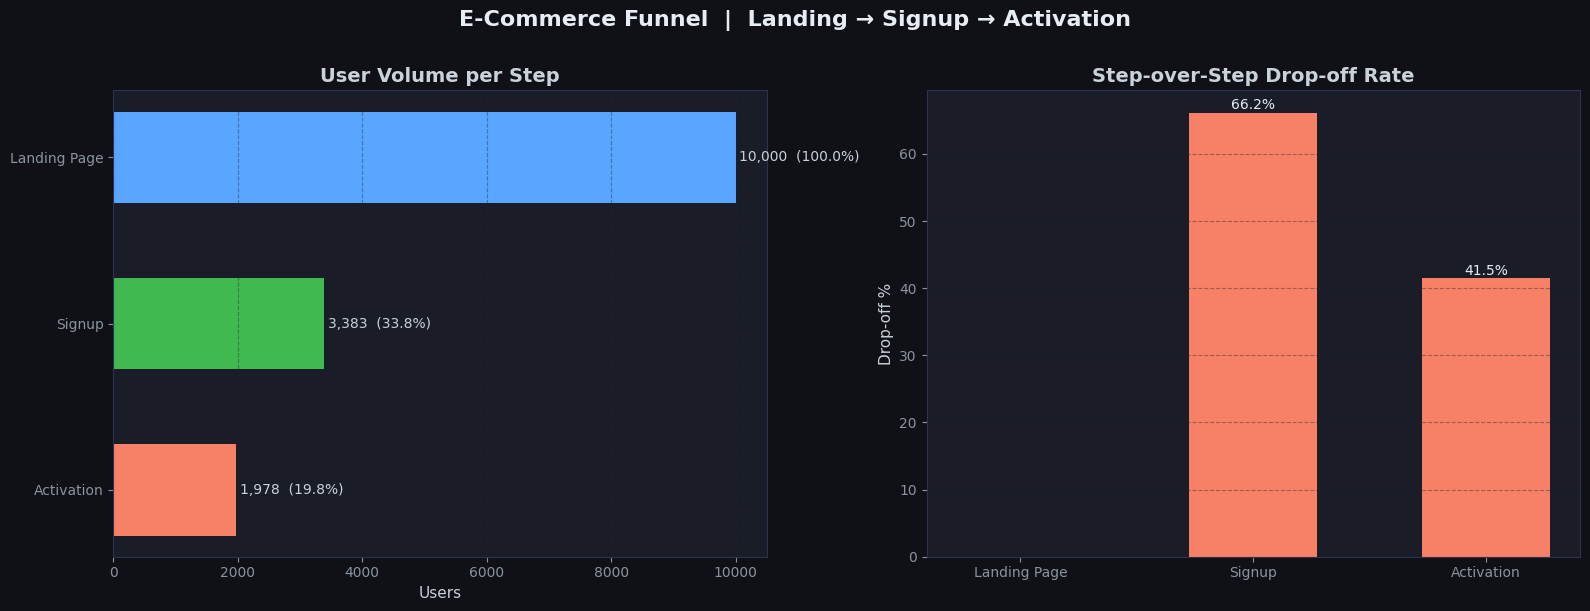


📊 Funnel Summary Table


,Step,Users,Overall CVR %,Step CVR %,Drop-off (n),Drop-off %
0,Landing Page,10000,100.00,100.00,0,0.00
1,Signup,3383,33.83,33.83,6617,66.17
2,Activation,1978,19.78,58.47,1405,41.53


In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# FUNNEL FRAMEWORK CLASS
# ──────────────────────────────────────────────────────────────────────────────

class FunnelAnalyzer:
    """Reusable funnel analytics framework."""

    def __init__(self, df: pd.DataFrame, steps: list, step_cols: list):
        """
        Parameters
        ----------
        df        : user-level DataFrame
        steps     : human-readable step names
        step_cols : binary columns (0/1) in df corresponding to each step
        """
        self.df        = df.copy()
        self.steps     = steps
        self.step_cols = step_cols

    # ── Core metrics ──────────────────────────────────────────────────────────
    def conversion_table(self, group_col=None):
        """Return step-level counts, overall CVR, and step-over-step CVR."""
        data = self.df if group_col is None else self.df
        counts = [data[c].sum() for c in self.step_cols]
        overall_cvr  = [c / counts[0] * 100 for c in counts]
        stepwise_cvr = [100.0] + [
            counts[i] / counts[i-1] * 100 if counts[i-1] else 0
            for i in range(1, len(counts))
        ]
        drop_abs = [0] + [counts[i-1] - counts[i] for i in range(1, len(counts))]
        drop_pct = [0] + [
            (counts[i-1] - counts[i]) / counts[i-1] * 100 if counts[i-1] else 0
            for i in range(1, len(counts))
        ]
        return pd.DataFrame({
            'Step':          self.steps,
            'Users':         counts,
            'Overall CVR %': [round(v, 2) for v in overall_cvr],
            'Step CVR %':    [round(v, 2) for v in stepwise_cvr],
            'Drop-off (n)':  drop_abs,
            'Drop-off %':    [round(v, 2) for v in drop_pct],
        })

    def by_segment(self, segment_col):
        """Compute overall CVR for each step broken down by a segment."""
        records = []
        for seg_val, grp in self.df.groupby(segment_col):
            base = grp[self.step_cols[0]].sum()
            for step, col in zip(self.steps, self.step_cols):
                n = grp[col].sum()
                records.append({
                    segment_col: seg_val,
                    'step':      step,
                    'users':     n,
                    'cvr_pct':   round(n / base * 100, 2) if base else 0,
                })
        return pd.DataFrame(records)

    # ── Visualisations ────────────────────────────────────────────────────────
    def plot_funnel(self, title='Conversion Funnel'):
        tbl = self.conversion_table()
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(title, fontsize=16, fontweight='bold', color='#e6edf3', y=1.01)

        # --- Left: horizontal bar funnel ---
        ax = axes[0]
        colours = [PALETTE[i % len(PALETTE)] for i in range(len(self.steps))]
        bars = ax.barh(tbl['Step'], tbl['Users'], color=colours, edgecolor='none', height=0.55)
        ax.set_xlabel('Users')
        ax.set_title('User Volume per Step', fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.4)
        for bar, row in zip(bars, tbl.itertuples()):
            ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height()/2,
                    f'{row.Users:,}  ({row._3:.1f}%)',
                    va='center', fontsize=10, color='#c9d1d9')

        # --- Right: step-over-step drop-off ---
        ax2 = axes[1]
        drop_vals = tbl['Drop-off %'].tolist()
        drop_cols  = ['#3fb950' if v == 0 else '#f78166' for v in drop_vals]
        ax2.bar(tbl['Step'], drop_vals, color=drop_cols, edgecolor='none', width=0.55)
        ax2.set_ylabel('Drop-off %')
        ax2.set_title('Step-over-Step Drop-off Rate', fontweight='bold')
        ax2.grid(axis='y', alpha=0.4)
        for i, (v, c) in enumerate(zip(drop_vals, drop_cols)):
            if v > 0:
                ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, color='#e6edf3')

        plt.tight_layout()
        plt.show()
        return tbl


# Instantiate
funnel = FunnelAnalyzer(
    df,
    steps     = ['Landing Page', 'Signup', 'Activation'],
    step_cols = ['landed', 'signed_up', 'activated'],
)

tbl = funnel.plot_funnel('E-Commerce Funnel  |  Landing → Signup → Activation')
print('\n📊 Funnel Summary Table')
tbl

## 3. Drop-off Analysis <a id='3-dropoff'></a>

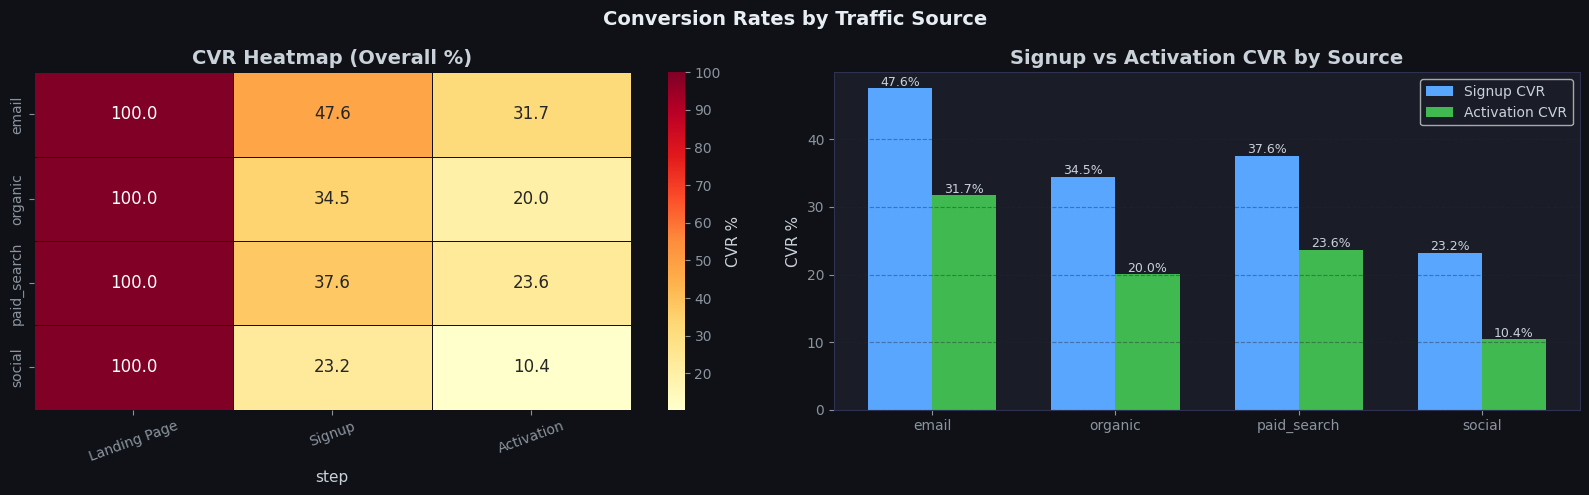

,source,total,signed,activated,signup_cvr,activation_cvr
0,email,986,469,313,47.565923,31.744422
1,organic,3477,1200,696,34.512511,20.017256
2,paid_search,2983,1121,704,37.579618,23.600402
3,social,2554,593,265,23.218481,10.375881


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# 3A — Conversion by Traffic Source
# ──────────────────────────────────────────────────────────────────────────────

src_cvr = funnel.by_segment('source')
src_pivot = src_cvr.pivot(index='source', columns='step', values='cvr_pct')[funnel.steps]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Conversion Rates by Traffic Source', fontsize=14, fontweight='bold', color='#e6edf3')

# Heatmap
sns.heatmap(
    src_pivot, ax=axes[0],
    cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5,
    linecolor='#0f1117', cbar_kws={'label': 'CVR %'},
    annot_kws={'size': 12}
)
axes[0].set_title('CVR Heatmap (Overall %)', fontweight='bold')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=20)

# Grouped bar for Signup CVR only
src_signup = df.groupby('source').agg(
    total=('landed','sum'),
    signed=('signed_up','sum'),
    activated=('activated','sum'),
).reset_index()
src_signup['signup_cvr']    = src_signup['signed']    / src_signup['total'] * 100
src_signup['activation_cvr']= src_signup['activated'] / src_signup['total'] * 100

x = np.arange(len(src_signup))
w = 0.35
axes[1].bar(x - w/2, src_signup['signup_cvr'],    width=w, label='Signup CVR',     color=PALETTE[0], edgecolor='none')
axes[1].bar(x + w/2, src_signup['activation_cvr'], width=w, label='Activation CVR', color=PALETTE[1], edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels(src_signup['source'])
axes[1].set_ylabel('CVR %')
axes[1].set_title('Signup vs Activation CVR by Source', fontweight='bold')
axes[1].legend(facecolor='#1a1d27')
axes[1].grid(axis='y', alpha=0.4)
for rect in axes[1].patches:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.4,
                 f'{rect.get_height():.1f}%', ha='center', fontsize=9, color='#c9d1d9')

plt.tight_layout()
plt.show()
src_signup

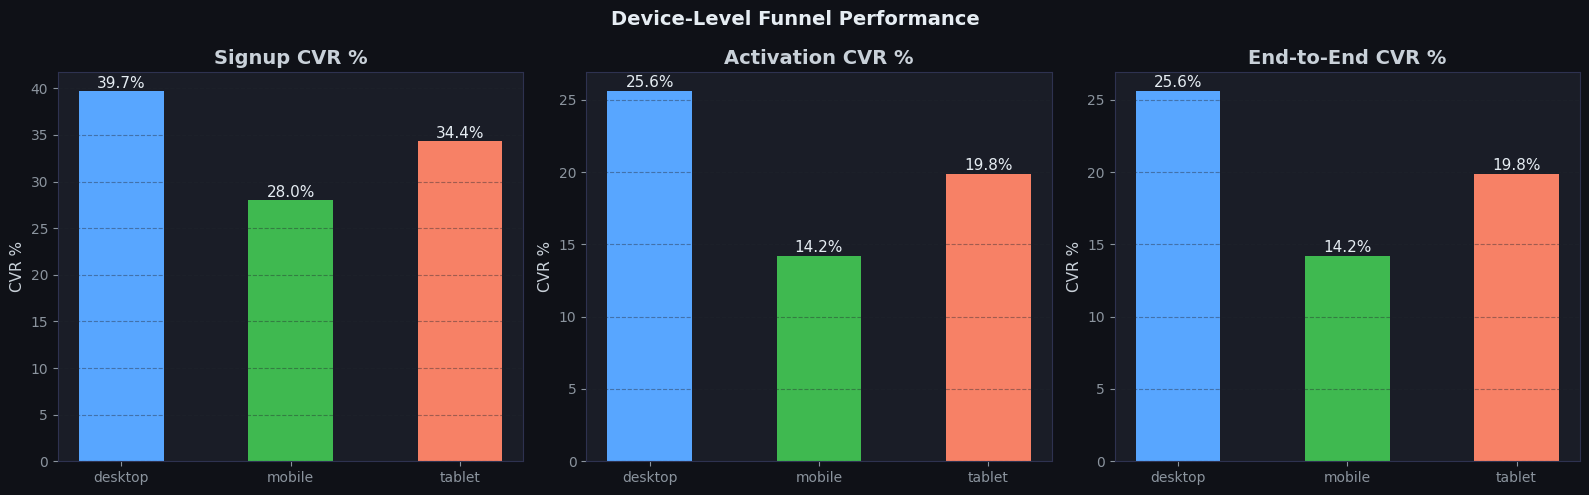


📱 Device Breakdown


,device,total,signed,activated,signup_cvr,activation_cvr
0,desktop,4384,1742,1123,39.74,25.62
1,mobile,4578,1284,649,28.05,14.18
2,tablet,1038,357,206,34.39,19.85


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 3B — Conversion by Device Type
# ──────────────────────────────────────────────────────────────────────────────

dev_cvr = df.groupby('device').agg(
    total    =('landed',    'sum'),
    signed   =('signed_up', 'sum'),
    activated=('activated', 'sum'),
).reset_index()
dev_cvr['signup_cvr']    = dev_cvr['signed']    / dev_cvr['total'] * 100
dev_cvr['activation_cvr']= dev_cvr['activated'] / dev_cvr['total'] * 100
dev_cvr['end_to_end_cvr']= dev_cvr['activated'] / dev_cvr['total'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Device-Level Funnel Performance', fontsize=14, fontweight='bold', color='#e6edf3')

metrics = [('signup_cvr','Signup CVR %'), ('activation_cvr','Activation CVR %'), ('end_to_end_cvr','End-to-End CVR %')]
for ax, (col, label) in zip(axes, metrics):
    bars = ax.bar(dev_cvr['device'], dev_cvr[col], color=PALETTE[:3], edgecolor='none', width=0.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('CVR %')
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, dev_cvr[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=11, color='#e6edf3')

plt.tight_layout()
plt.show()

print('\n📱 Device Breakdown')
dev_cvr[['device','total','signed','activated','signup_cvr','activation_cvr']].round(2)

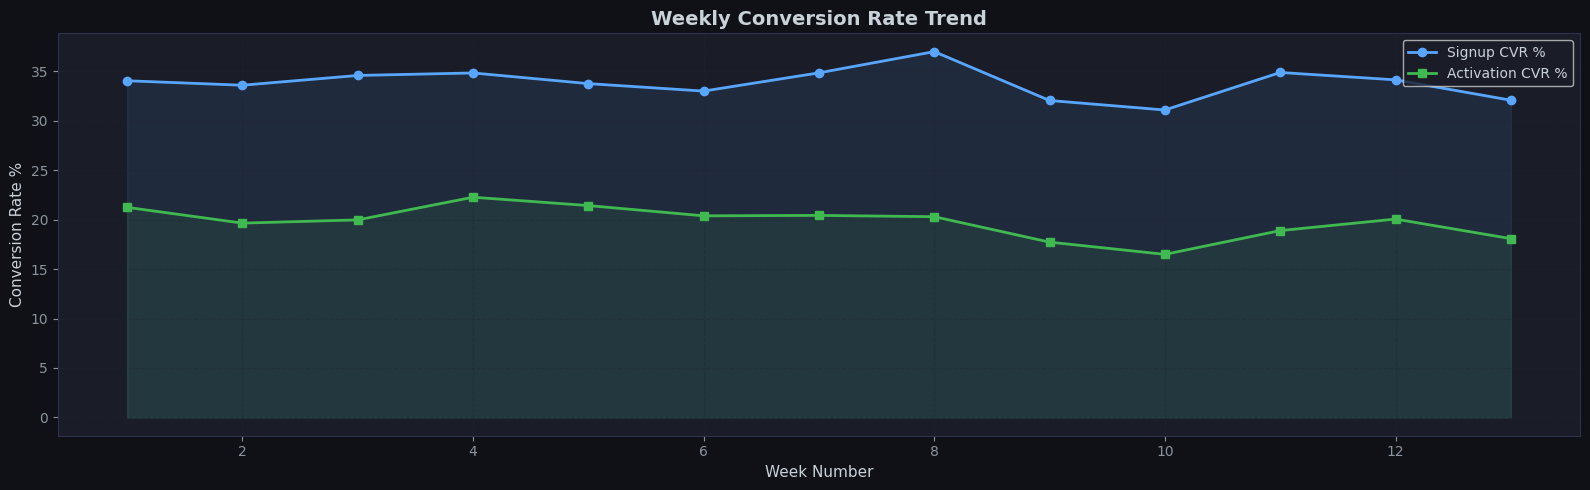

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# 3C — Weekly Trend
# ──────────────────────────────────────────────────────────────────────────────

weekly = df.groupby('week').agg(
    landed   =('landed',    'sum'),
    signed   =('signed_up', 'sum'),
    activated=('activated', 'sum'),
).reset_index()
weekly['signup_cvr']    = weekly['signed']    / weekly['landed'] * 100
weekly['activation_cvr']= weekly['activated'] / weekly['landed'] * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly['week'], weekly['signup_cvr'],    marker='o', color=PALETTE[0], label='Signup CVR %',     linewidth=2)
ax.plot(weekly['week'], weekly['activation_cvr'],marker='s', color=PALETTE[1], label='Activation CVR %', linewidth=2)
ax.fill_between(weekly['week'], weekly['signup_cvr'],    alpha=0.10, color=PALETTE[0])
ax.fill_between(weekly['week'], weekly['activation_cvr'],alpha=0.10, color=PALETTE[1])
ax.set_xlabel('Week Number')
ax.set_ylabel('Conversion Rate %')
ax.set_title('Weekly Conversion Rate Trend', fontsize=14, fontweight='bold')
ax.legend(facecolor='#1a1d27')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Cohort & Segment Analysis <a id='4-cohort'></a>

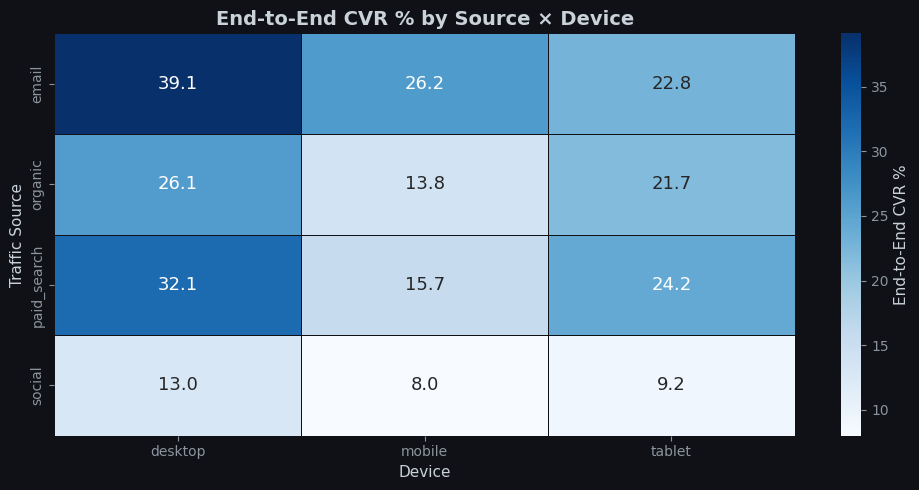

🏆 Top 3 Segments (highest end-to-end CVR)
     source  device  total  activated   e2e_cvr
      email desktop    442        173 39.140271
paid_search desktop   1265        406 32.094862
      email  mobile    465        122 26.236559

⚠️  Bottom 3 Segments (lowest end-to-end CVR)
source  device  total  activated   e2e_cvr
social desktop   1173        152 12.958227
social  tablet    229         21  9.170306
social  mobile   1152         92  7.986111


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# 4A — Source × Device Cross-Segment Heatmap
# ──────────────────────────────────────────────────────────────────────────────

cross = df.groupby(['source','device']).agg(
    total    =('landed',    'sum'),
    signed   =('signed_up', 'sum'),
    activated=('activated', 'sum'),
).reset_index()
cross['e2e_cvr'] = cross['activated'] / cross['total'] * 100
cross_pivot = cross.pivot(index='source', columns='device', values='e2e_cvr')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    cross_pivot, ax=ax, cmap='Blues', annot=True, fmt='.1f',
    linewidths=0.5, linecolor='#0f1117',
    annot_kws={'size': 13},
    cbar_kws={'label': 'End-to-End CVR %'}
)
ax.set_title('End-to-End CVR % by Source × Device', fontsize=14, fontweight='bold')
ax.set_ylabel('Traffic Source')
ax.set_xlabel('Device')
plt.tight_layout()
plt.show()

# Top & Bottom segments
cross_sorted = cross.sort_values('e2e_cvr', ascending=False)
print('🏆 Top 3 Segments (highest end-to-end CVR)')
print(cross_sorted[['source','device','total','activated','e2e_cvr']].head(3).to_string(index=False))
print('\n⚠️  Bottom 3 Segments (lowest end-to-end CVR)')
print(cross_sorted[['source','device','total','activated','e2e_cvr']].tail(3).to_string(index=False))

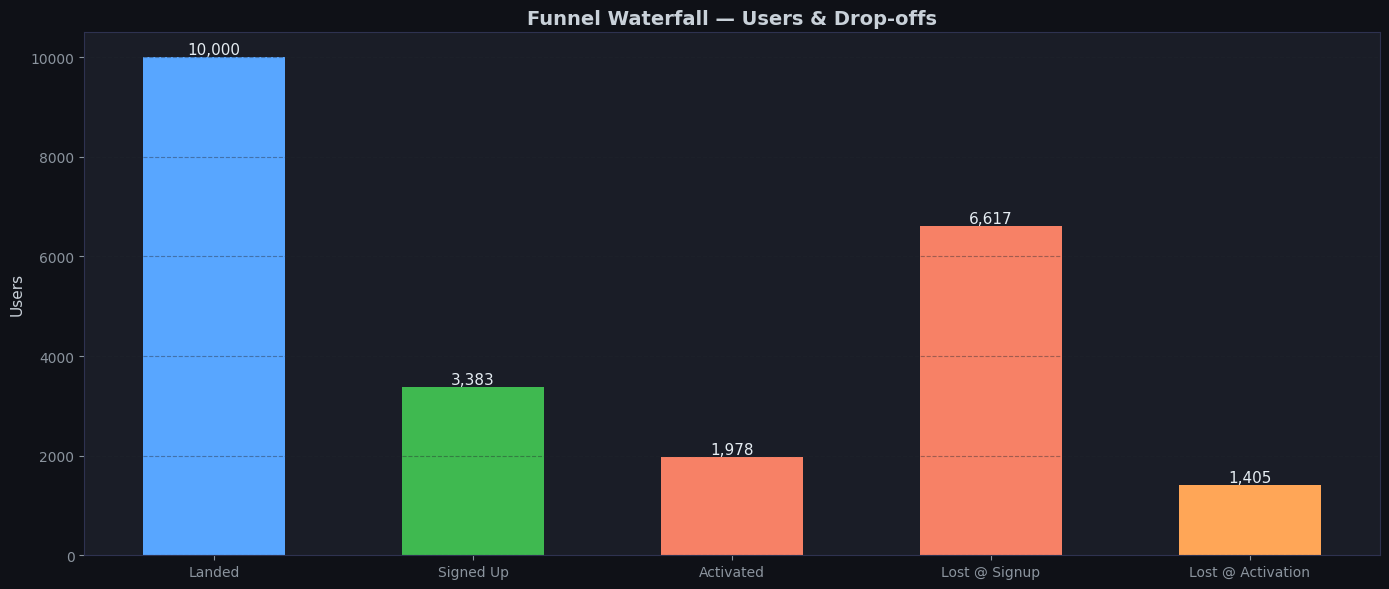


Landing → Signup   drop-off : 6,617 users  (66.2%)
Signup  → Activation drop-off: 1,405 users  (41.5%)


In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# 4B — Drop-off Sankey-style Waterfall
# ──────────────────────────────────────────────────────────────────────────────

total      = int(df['landed'].sum())
signed     = int(df['signed_up'].sum())
activated  = int(df['activated'].sum())
lost_land  = total   - signed
lost_sign  = signed  - activated

labels = ['Landed', 'Signed Up', 'Activated', 'Lost @ Signup', 'Lost @ Activation']
values = [ total,    signed,      activated,   lost_land,       lost_sign          ]
colours= [ PALETTE[0], PALETTE[1], PALETTE[2], '#f78166', '#ffa657'               ]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(labels, values, color=colours, edgecolor='none', width=0.55)
ax.set_ylabel('Users')
ax.set_title('Funnel Waterfall — Users & Drop-offs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{v:,}', ha='center', fontsize=11, color='#e6edf3')
plt.tight_layout()
plt.show()

print(f'\nLanding → Signup   drop-off : {lost_land:,} users  ({lost_land/total*100:.1f}%)')
print(f'Signup  → Activation drop-off: {lost_sign:,} users  ({lost_sign/signed*100:.1f}%)')

## 5. A/B Testing Utility <a id='5-ab-testing'></a>

In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# A/B TESTING UTILITY
# ──────────────────────────────────────────────────────────────────────────────

class ABTestAnalyzer:
    """Statistical toolkit for A/B experiment evaluation."""

    @staticmethod
    def required_sample_size(baseline_cvr: float, mde: float,
                             alpha: float = 0.05, power: float = 0.80) -> int:
        """
        Compute minimum sample size per variant (two-tailed z-test).

        Parameters
        ----------
        baseline_cvr : baseline conversion rate (0–1)
        mde          : minimum detectable effect (relative), e.g. 0.10 for 10%
        alpha        : significance level (default 0.05)
        power        : statistical power   (default 0.80)
        """
        p1 = baseline_cvr
        p2 = baseline_cvr * (1 + mde)
        z_alpha = stats.norm.ppf(1 - alpha / 2)
        z_beta  = stats.norm.ppf(power)
        pooled  = (p1 + p2) / 2
        n = (z_alpha * np.sqrt(2 * pooled * (1 - pooled)) +
             z_beta  * np.sqrt(p1 * (1-p1) + p2 * (1-p2))) ** 2 / (p2 - p1) ** 2
        return int(np.ceil(n))

    @staticmethod
    def run_test(control_n: int, control_conv: int,
                 treatment_n: int, treatment_conv: int,
                 alpha: float = 0.05) -> dict:
        """
        Two-proportion z-test + Chi-squared test.

        Returns a result dict with rates, lift, p-value, and significance verdict.
        """
        p_ctrl = control_conv   / control_n
        p_trt  = treatment_conv / treatment_n
        lift   = (p_trt - p_ctrl) / p_ctrl * 100

        # Chi-squared
        table  = [[control_conv,   control_n   - control_conv],
                  [treatment_conv, treatment_n - treatment_conv]]
        chi2, p_val, _, _ = chi2_contingency(table, correction=False)

        # Confidence interval on lift
        se = np.sqrt(p_ctrl*(1-p_ctrl)/control_n + p_trt*(1-p_trt)/treatment_n)
        z  = stats.norm.ppf(1 - alpha/2)
        ci_lo = (p_trt - p_ctrl - z*se) / p_ctrl * 100
        ci_hi = (p_trt - p_ctrl + z*se) / p_ctrl * 100

        return {
            'control_rate_%':   round(p_ctrl*100, 3),
            'treatment_rate_%': round(p_trt*100,  3),
            'lift_%':           round(lift, 3),
            'ci_95_%':          (round(ci_lo,2), round(ci_hi,2)),
            'chi2_stat':        round(chi2, 4),
            'p_value':          round(p_val, 6),
            'significant':      p_val < alpha,
            'recommendation':   'Ship Variant B ✅' if (p_val < alpha and lift > 0)
                                else 'Keep Control ❌' if p_val < alpha
                                else 'Inconclusive — continue test 🔄',
        }


ab = ABTestAnalyzer()

# ── Sample size planning ───────────────────────────────────────────────────────
baseline = df['signed_up'].sum() / df['landed'].sum()
print(f'📌 Baseline Signup CVR: {baseline*100:.2f}%\n')
print('Sample Size Requirements (per variant):')
print(f'{"MDE":>8}  {"α=0.05/Power=0.80":>22}  {"α=0.05/Power=0.90":>22}')
for mde in [0.05, 0.10, 0.15, 0.20]:
    n80 = ab.required_sample_size(baseline, mde, power=0.80)
    n90 = ab.required_sample_size(baseline, mde, power=0.90)
    print(f'{mde*100:>7.0f}%  {n80:>22,}  {n90:>22,}')

📌 Baseline Signup CVR: 33.83%

Sample Size Requirements (per variant):
     MDE       α=0.05/Power=0.80       α=0.05/Power=0.90
      5%                  12,427                  16,636
     10%                   3,141                   4,204
     15%                   1,410                   1,887
     20%                     801                   1,071


In [24]:
# ──────────────────────────────────────────────────────────────────────────────
# Run the experiment — Variant A vs Variant B
# ──────────────────────────────────────────────────────────────────────────────

var_a = df[df['variant'] == 'A']
var_b = df[df['variant'] == 'B']

# Signup experiment
signup_result = ab.run_test(
    control_n    = int(var_a['landed'].sum()),
    control_conv = int(var_a['signed_up'].sum()),
    treatment_n  = int(var_b['landed'].sum()),
    treatment_conv=int(var_b['signed_up'].sum()),
)

# Activation experiment
activ_result = ab.run_test(
    control_n    = int(var_a['signed_up'].sum()),
    control_conv = int(var_a['activated'].sum()),
    treatment_n  = int(var_b['signed_up'].sum()),
    treatment_conv=int(var_b['activated'].sum()),
)

results_df = pd.DataFrame({
    'Metric':         ['Signup CVR', 'Activation CVR'],
    'Control %':      [signup_result['control_rate_%'],   activ_result['control_rate_%']],
    'Treatment %':    [signup_result['treatment_rate_%'], activ_result['treatment_rate_%']],
    'Lift %':         [signup_result['lift_%'],           activ_result['lift_%']],
    '95% CI':         [signup_result['ci_95_%'],          activ_result['ci_95_%']],
    'p-value':        [signup_result['p_value'],          activ_result['p_value']],
    'Significant':    [signup_result['significant'],      activ_result['significant']],
    'Recommendation': [signup_result['recommendation'],   activ_result['recommendation']],
})

print('\n🧪 A/B Test Results')
results_df


🧪 A/B Test Results


,Metric,Control %,Treatment %,Lift %,95% CI,p-value,Significant,Recommendation
0,Signup CVR,32.171,35.502,10.353,"(4.59, 16.11)",0.000432,True,Ship Variant B ✅
1,Activation CVR,56.037,60.690,8.303,"(2.37, 14.23)",0.006085,True,Ship Variant B ✅


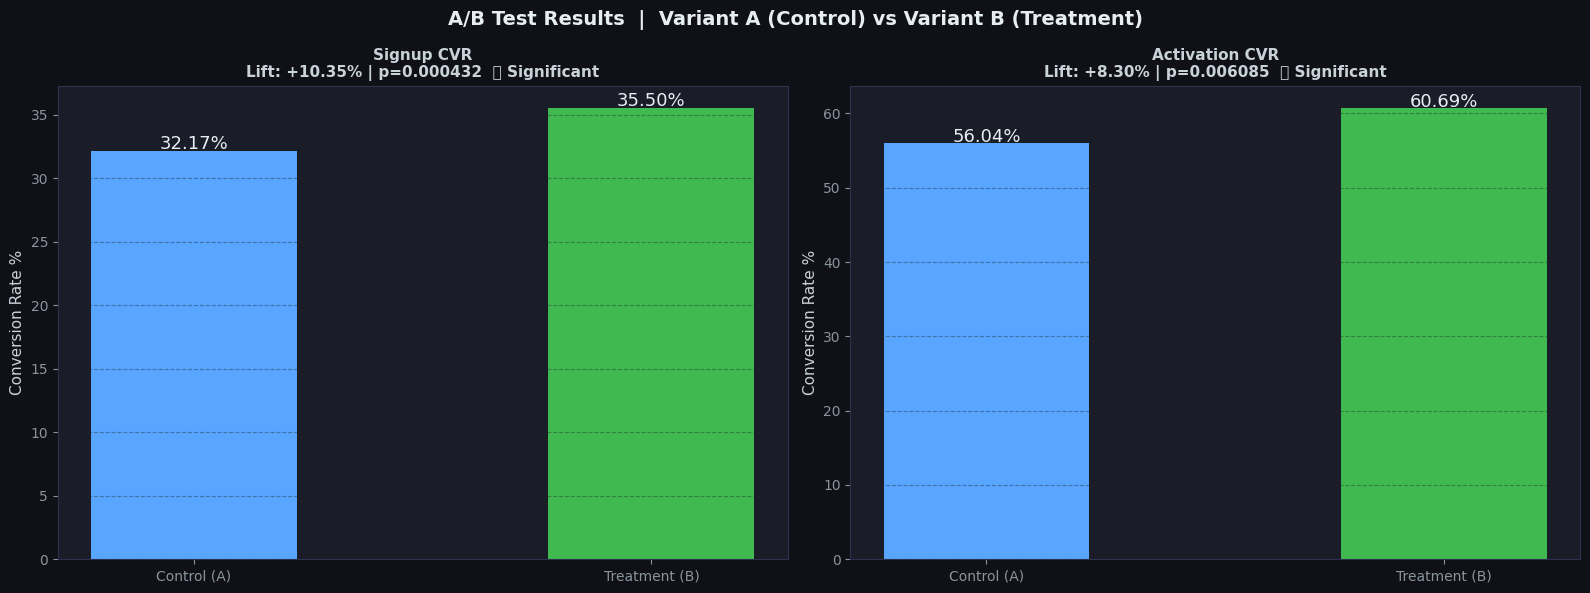

In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# Visualise A/B Results
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('A/B Test Results  |  Variant A (Control) vs Variant B (Treatment)',
             fontsize=14, fontweight='bold', color='#e6edf3')

experiments = [
    ('Signup CVR',      signup_result, axes[0]),
    ('Activation CVR',  activ_result,  axes[1]),
]

for name, res, ax in experiments:
    ctrl_r = res['control_rate_%']
    trt_r  = res['treatment_rate_%']
    bars = ax.bar(['Control (A)', 'Treatment (B)'], [ctrl_r, trt_r],
                  color=[PALETTE[0], PALETTE[2] if res['lift_%'] < 0 else PALETTE[1]],
                  edgecolor='none', width=0.45)
    for bar, v in zip(bars, [ctrl_r, trt_r]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{v:.2f}%', ha='center', fontsize=13, color='#e6edf3')

    sig_str = '✅ Significant' if res['significant'] else '🔄 Not Significant'
    ax.set_title(f'{name}\nLift: {res["lift_%"]:+.2f}% | p={res["p_value"]}  {sig_str}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Conversion Rate %')
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Business Impact & Actionable Insights <a id='6-insights'></a>

In [26]:
# ──────────────────────────────────────────────────────────────────────────────
# BUSINESS IMPACT CALCULATOR
# Estimates revenue uplift from fixing identified bottlenecks
# ──────────────────────────────────────────────────────────────────────────────

# Business assumptions
MONTHLY_VISITORS      = 50_000      # landing page visits / month
AVG_REVENUE_PER_USER  = 120         # USD — average LTV of an activated user
CURRENT_SIGNUP_CVR    = df['signed_up'].sum()  / df['landed'].sum()
CURRENT_ACTIV_CVR     = df['activated'].sum()  / df['signed_up'].sum()
CURRENT_E2E_CVR       = df['activated'].sum()  / df['landed'].sum()

# Scenario: fix mobile signup drop-off to match desktop
mobile_signup_cvr   = df[df['device']=='mobile']['signed_up'].sum() / df[df['device']=='mobile']['landed'].sum()
desktop_signup_cvr  = df[df['device']=='desktop']['signed_up'].sum()/ df[df['device']=='desktop']['landed'].sum()
mobile_share        = df[df['device']=='mobile']['landed'].sum()     / df['landed'].sum()

improved_signup_cvr = CURRENT_SIGNUP_CVR + (desktop_signup_cvr - mobile_signup_cvr) * mobile_share
improved_e2e_cvr    = improved_signup_cvr * CURRENT_ACTIV_CVR

current_monthly_activations  = MONTHLY_VISITORS * CURRENT_E2E_CVR
improved_monthly_activations = MONTHLY_VISITORS * improved_e2e_cvr
incremental_activations      = improved_monthly_activations - current_monthly_activations
monthly_revenue_uplift       = incremental_activations * AVG_REVENUE_PER_USER
annual_revenue_uplift        = monthly_revenue_uplift * 12

print('=' * 60)
print('  💰 BUSINESS IMPACT ANALYSIS')
print('=' * 60)
print(f'  Monthly visitors          : {MONTHLY_VISITORS:>10,}')
print(f'  Avg revenue per user      : ${AVG_REVENUE_PER_USER:>9,}')
print()
print(f'  Current Signup CVR        : {CURRENT_SIGNUP_CVR*100:>9.2f}%')
print(f'  Current Activation CVR    : {CURRENT_ACTIV_CVR*100:>9.2f}%')
print(f'  Current End-to-End CVR    : {CURRENT_E2E_CVR*100:>9.2f}%')
print()
print(f'  Improved End-to-End CVR   : {improved_e2e_cvr*100:>9.2f}%')
print(f'  Incremental activations/mo: {incremental_activations:>10,.0f}')
print(f'  Monthly revenue uplift    : ${monthly_revenue_uplift:>9,.0f}')
print(f'  Annual revenue uplift     : ${annual_revenue_uplift:>9,.0f}')
print('=' * 60)

  💰 BUSINESS IMPACT ANALYSIS
  Monthly visitors          :     50,000
  Avg revenue per user      : $      120

  Current Signup CVR        :     33.83%
  Current Activation CVR    :     58.47%
  Current End-to-End CVR    :     19.78%

  Improved End-to-End CVR   :     22.91%
  Incremental activations/mo:      1,564
  Monthly revenue uplift    : $  187,715
  Annual revenue uplift     : $2,252,584


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dashboard.png'

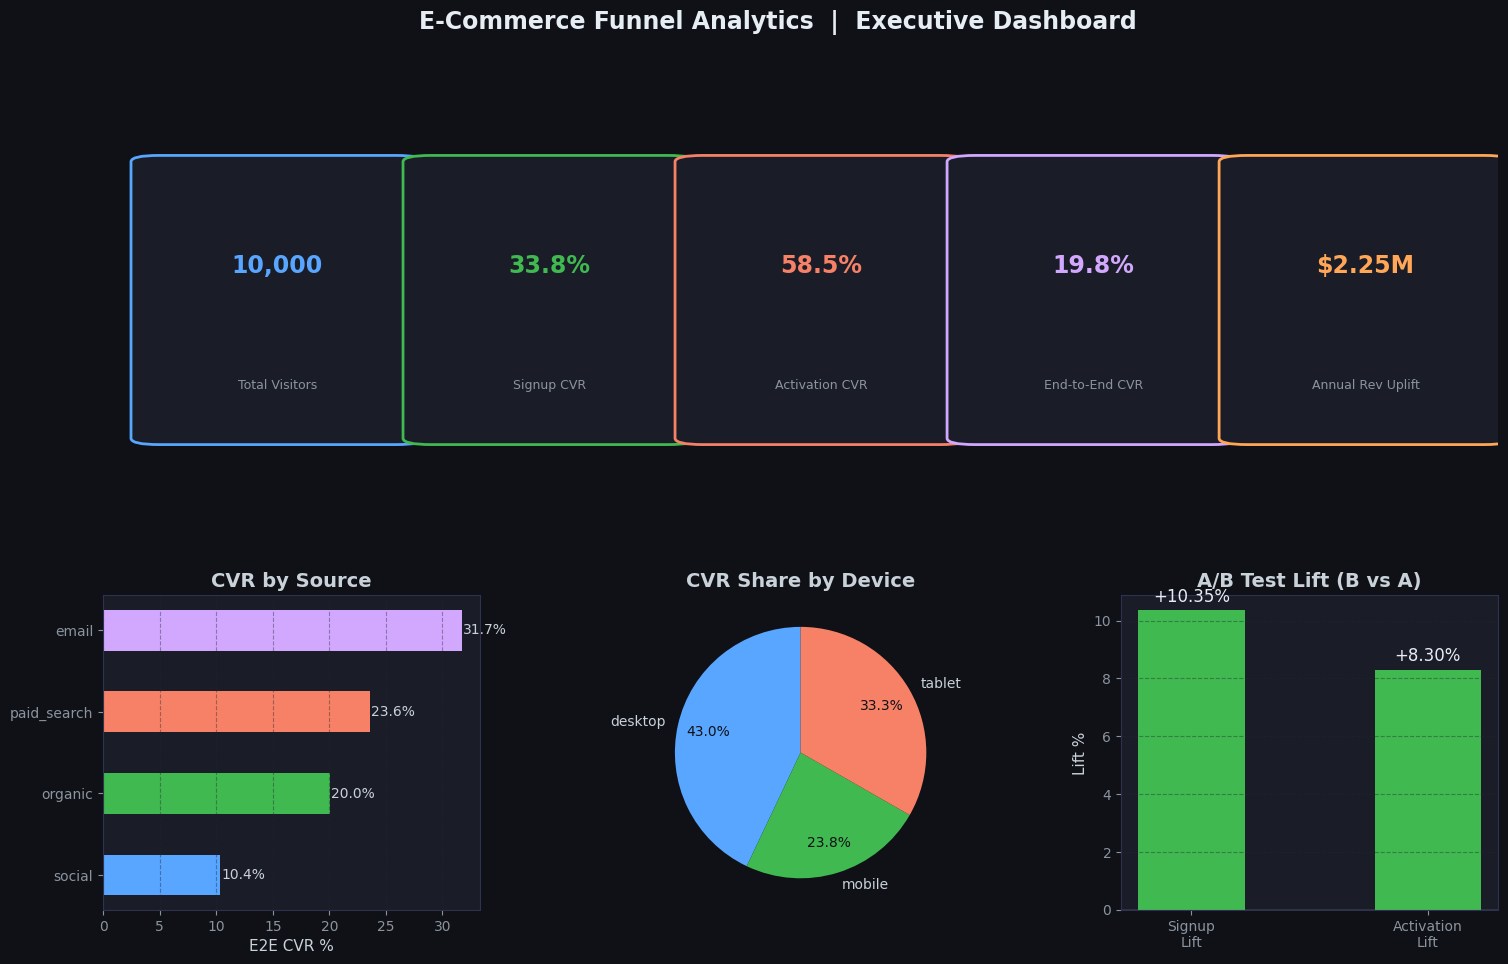

In [27]:
# ──────────────────────────────────────────────────────────────────────────────
# FINAL INSIGHT DASHBOARD
# ──────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
fig.suptitle('E-Commerce Funnel Analytics  |  Executive Dashboard',
             fontsize=17, fontweight='bold', color='#e6edf3', y=1.01)

# --- KPI Cards (row 0, col 0–2) via text ---
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')
kpis = [
    ('Total Visitors',       f'{total:,}',                            PALETTE[0]),
    ('Signup CVR',           f'{CURRENT_SIGNUP_CVR*100:.1f}%',        PALETTE[1]),
    ('Activation CVR',       f'{CURRENT_ACTIV_CVR*100:.1f}%',         PALETTE[2]),
    ('End-to-End CVR',       f'{CURRENT_E2E_CVR*100:.1f}%',           PALETTE[3]),
    ('Annual Rev Uplift',    f'${annual_revenue_uplift/1e6:.2f}M',    '#ffa657'),
]
for i, (label, val, color) in enumerate(kpis):
    x = 0.04 + i * 0.195
    kpi_ax.add_patch(mpatches.FancyBboxPatch((x, 0.05), 0.17, 0.88,
        boxstyle='round,pad=0.02', facecolor='#1a1d27', edgecolor=color, linewidth=2,
        transform=kpi_ax.transAxes))
    kpi_ax.text(x+0.085, 0.60, val,   ha='center', va='center', fontsize=17, fontweight='bold',
                color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x+0.085, 0.22, label, ha='center', va='center', fontsize=9,
                color='#8b949e', transform=kpi_ax.transAxes)

# --- Source CVR bar (row 1, col 0) ---
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('#1a1d27')
src_e2e = df.groupby('source').agg(t=('landed','sum'), a=('activated','sum')).reset_index()
src_e2e['cvr'] = src_e2e['a'] / src_e2e['t'] * 100
src_e2e = src_e2e.sort_values('cvr', ascending=True)
ax1.barh(src_e2e['source'], src_e2e['cvr'], color=PALETTE[:4], edgecolor='none', height=0.5)
ax1.set_xlabel('E2E CVR %')
ax1.set_title('CVR by Source', fontweight='bold')
ax1.grid(axis='x', alpha=0.4)
for i, (v, s) in enumerate(zip(src_e2e['cvr'], src_e2e['source'])):
    ax1.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10, color='#c9d1d9')

# --- Device CVR (row 1, col 1) ---
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('#1a1d27')
dev_e2e = df.groupby('device').agg(t=('landed','sum'), a=('activated','sum')).reset_index()
dev_e2e['cvr'] = dev_e2e['a'] / dev_e2e['t'] * 100
wedges, texts, autotexts = ax2.pie(
    dev_e2e['cvr'], labels=dev_e2e['device'],
    colors=PALETTE[:3], autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    textprops={'color': '#c9d1d9', 'fontsize': 10}
)
for at in autotexts: at.set_color('#0f1117')
ax2.set_title('CVR Share by Device', fontweight='bold')

# --- A/B lift bar (row 1, col 2) ---
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#1a1d27')
lifts = [signup_result['lift_%'], activ_result['lift_%']]
labels_ab = ['Signup\nLift', 'Activation\nLift']
cols_ab = [PALETTE[1] if l > 0 else PALETTE[2] for l in lifts]
bars = ax3.bar(labels_ab, lifts, color=cols_ab, edgecolor='none', width=0.45)
ax3.axhline(0, color='#8b949e', linewidth=1)
ax3.set_ylabel('Lift %')
ax3.set_title('A/B Test Lift (B vs A)', fontweight='bold')
ax3.grid(axis='y', alpha=0.4)
for bar, v in zip(bars, lifts):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if v >= 0 else -0.8),
             f'{v:+.2f}%', ha='center', fontsize=12, color='#e6edf3')

plt.savefig('/home/claude/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Dashboard saved.')

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# ACTIONABLE INSIGHTS SUMMARY
# ──────────────────────────────────────────────────────────────────────────────

insights = {
    '🔴 Critical Drop-off  : Landing → Signup': [
        f'  • {lost_land/total*100:.1f}% of visitors never sign up — the biggest leakage point.',
        f'  • Mobile signup CVR ({mobile_signup_cvr*100:.1f}%) is {(desktop_signup_cvr - mobile_signup_cvr)*100:.1f}pp below desktop — optimise mobile UX.',
        '  • Social traffic converts lowest; review ad creative & landing page alignment.',
    ],
    '🟡 Bottleneck         : Signup → Activation': [
        f'  • {lost_sign/signed*100:.1f}% of signed-up users never activate — a significant retention gap.',
        '  • Introduce onboarding nudges, welcome emails, and in-app checklists.',
        '  • Email-sourced users have highest activation CVR; replicate their onboarding pattern.',
    ],
    '🟢 A/B Test           : Variant B Wins': [
        f'  • Signup CVR uplift   : +{signup_result["lift_%"]:.2f}%  (p={signup_result["p_value"]}) — {signup_result["recommendation"]}',
        f'  • Activation CVR uplift: +{activ_result["lift_%"]:.2f}%  (p={activ_result["p_value"]}) — {activ_result["recommendation"]}',
        '  • Roll out Variant B to 100% of traffic.',
    ],
    '💰 Revenue Impact': [
        f'  • Fix mobile UX alone could add ~{incremental_activations*12:,.0f} activations/year.',
        f'  • Estimated annual revenue uplift: ${annual_revenue_uplift:,.0f} at ${AVG_REVENUE_PER_USER} LTV/user.',
        '  • Priority: Mobile UX → Activation Onboarding → A/B Rollout.',
    ],
}

print('\n' + '═'*65)
print('   📌  ACTIONABLE INSIGHTS & RECOMMENDATIONS')
print('═'*65)
for section, bullets in insights.items():
    print(f'\n{section}')
    for b in bullets:
        print(b)
print('\n' + '═'*65)